# ConvNeXtTiny para clasificacion de aves CUB-200-2011


## 1. Importar librerias y configurar parametros


In [ ]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.convnext import ConvNeXtTiny
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
DATASET_NAME = "caltech_birds2011"
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

#Generacion de rutas para guardar los datasets, resultados y modelos
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "modelos" else Path.cwd()
TFDS_DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "resultados"
MODELS_DIR = PROJECT_ROOT / "modelos_guardados"

TFDS_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


print("Dataset cache:", TFDS_DATA_DIR)


## 2. Cargar el dataset

Usamos splits directos de TFDS para evitar filtros manuales, indices y `steps_per_epoch`. El split oficial `train` se divide en entrenamiento y validacion; el split oficial `test` queda para evaluacion final.

Aqui definimos en que proporcion dividimos los datos haciendo uso del metodo de `División Fija`


In [ ]:

TRAIN_SPLIT = "train[:80%]"
VAL_SPLIT = "train[80%:]"
TEST_SPLIT = "test"
print("Splits:", TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT)

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    DATASET_NAME,
    split=[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT],
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
    data_dir=str(TFDS_DATA_DIR),
)

num_classes = info.features["label"].num_classes
class_names = info.features["label"].names

print(f"Clases de pajaros: {num_classes}")
print(f"Cantidad de datos para Entrenar: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"Cantidad de datos para Validación: {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Cantidad de datos para Test: {tf.data.experimental.cardinality(ds_test_raw).numpy()}")


Clases de pajaros: 200
Cantidad de datos para Entrenar: 4795
Cantidad de datos para Validación: 1199
Cantidad de datos para Test: 5794


## 3. Visualizar algunas imagenes del dataset


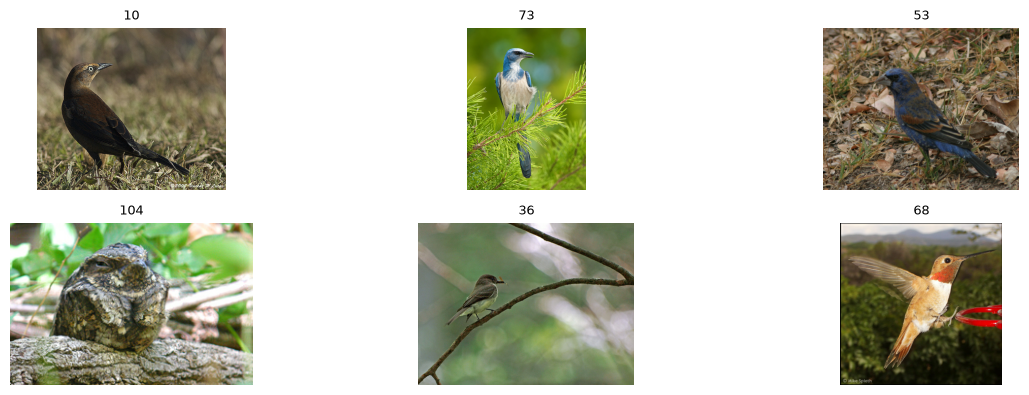

In [14]:
plt.figure(figsize=(12, 6))
for i, (imagen, etiqueta) in enumerate(ds_train_raw.take(6)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagen)
    plt.title(class_names[int(etiqueta.numpy())], fontsize=9)
    plt.axis("off")
plt.tight_layout()


## 4. Funcion para Graficar entrenamiento y mostrar tabla de valores

In [ ]:
def plot_training_history(history):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["accuracy"], label="train")
    axes[0].plot(history_df["val_accuracy"], label="validation")
    axes[0].set_title("Accuracy (Precisión)")
    axes[0].set_xlabel("Epocas")
    axes[0].set_ylabel("Precisión")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="train")
    axes[1].plot(history_df["val_loss"], label="validation")
    axes[1].set_title("Función de Loss")
    axes[1].set_xlabel("Epocas")
    axes[1].set_ylabel("Error")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return history_df

## 5. Preprocesar datos

CUB tiene imagenes de tamaños variables. Usamos `resize_with_pad` para llevarlas a `224x224` sin deformar la proporcion. ConvNeXtTiny incluye su propio preprocesamiento interno con `include_preprocessing=True`.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image(imagen, etiqueta):
    """
    Normalizamos las imagenes, las adaptamos a como las pide el modelo y preparamos su etiqueta.

    Args:
        imagen: Tensor con la imagen original de CUB-200-2011.
        etiqueta: Indice entero de la clase.

    Returns:
        tuple: Imagen preprocesada y etiqueta entera.
    """

    imagen = tf.image.resize_with_pad(imagen, IMG_SIZE, IMG_SIZE)
    imagen = tf.cast(imagen, tf.float32)
    etiqueta = tf.cast(etiqueta, tf.int32)
    return imagen, etiqueta


def prepare_dataset(dataset, training=False):
    """

    Aplica el preprocesamiento a todos los conjuntos del dataset. Si se indica entrenamiento, 
    mezcla los ejemplos antes de agruparlos en batches. 
    Prefetch prepara un batch y lo manda a entrenar, en paralelo prepara el siguiente Batch.

    Args:
        dataset: Dataset de TensorFlow con pares (imagen, etiqueta).
        training: Si es True, aplica shuffle para entrenamiento.

    Returns:
        tf.data.Dataset: Dataset listo para ser consumido por model.fit o model.evaluate.
    """

    dataset = dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        dataset = dataset.shuffle(1024, seed=SEED, reshuffle_each_iteration=True)
        
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = prepare_dataset(ds_train_raw, training=True)
val_ds = prepare_dataset(ds_val_raw)
test_ds = prepare_dataset(ds_test_raw)

for images, labels in train_ds.take(1):
    print("Batch de imagenes:", images.shape)
    print("Batch de etiquetas:", labels.shape)
    print("Label dtype:", labels.dtype)


2026-06-25 15:09:41.781859: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Batch imagenes: (16, 224, 224, 3)
Batch labels: (16,)
Label dtype: <dtype: 'int32'>


2026-06-25 15:09:43.174798: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 6. Definir el modelo base


In [7]:
base_model = ConvNeXtTiny(
    weights="imagenet",
    include_top=False,
    include_preprocessing=True,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs, name="ConvNeXtTiny")
model.summary()


Model: "ConvNeXtTiny"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │       153,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,973,928 (106.71 MB)

 Trainable params: 153,800 (600.78 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

## 7. Compilar y entrenar el modelo
Establecemos el `Algoritmo de Optimización`, la `Función de Coste` y las `metricas`


In [ ]:

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    #ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

history_df = plot_training_history(history)
display(history_df)


## 9. Evaluacion directa en conjunto de prueba


In [ ]:
test_metrics = model.evaluate(test_ds, verbose=1)

print("Metricas en conjunto de prueba:")
for name, value in zip(model.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")


## 10. Matriz de confusion y reporte de clasificacion


In [ ]:
# test_ds no esta barajado; asi y_true y y_pred quedan alineados.
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred = model.predict(test_ds, verbose=1).argmax(axis=1)

test_accuracy_from_predictions = np.mean(y_true == y_pred)
print(f"Accuracy en test ({model.name}): {test_accuracy_from_predictions:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).transpose()
display(report_df)


In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="viridis")
plt.title(f"Matriz de confusion - {model.name} ({len(class_names)} clases)")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.colorbar()
plt.tight_layout()
plt.show()

cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

pares_confundidos = [
    (cm_sin_diagonal[i, j], i, j)
    for i in range(len(cm_sin_diagonal))
    for j in range(len(cm_sin_diagonal))
    if cm_sin_diagonal[i, j] > 0
]
pares_confundidos.sort(reverse=True)

print("Top 10 pares mas confundidos:")
for cantidad, real_idx, pred_idx in pares_confundidos[:10]:
    print(f"  '{class_names[real_idx]}' confundida con '{class_names[pred_idx]}': {cantidad} veces")


## 11. Guardar resultados y modelo


In [ ]:
results = {
    "modelo": "ConvNeXtTiny",
    "dataset": DATASET_NAME,
    "train_split": TRAIN_SPLIT,
    "val_split": VAL_SPLIT,
    "test_split": TEST_SPLIT,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_configuradas": EPOCHS,
    "epochs_ejecutadas": len(history.history["loss"]),
    "learning_rate": LEARNING_RATE,
    "test_loss": test_metrics[0],
    "test_accuracy": test_metrics[1],
    "test_top_5_accuracy": test_metrics[2],
}

results_df = pd.DataFrame([results])
display(results_df)

results_path = RESULTS_DIR / "convnexttiny_simple_results.csv"
model_path = MODELS_DIR / "convnexttiny_cub200.keras"

results_df.to_csv(results_path, index=False)
model.save(model_path)

print("Resultados guardados en:", results_path)
print("Modelo guardado en:", model_path)
